#### Stochastic Degradation and Valuate at Risk (VaR)

This project utilizes a Weibull survival model 

Simulating 1000 stack lifetimes...


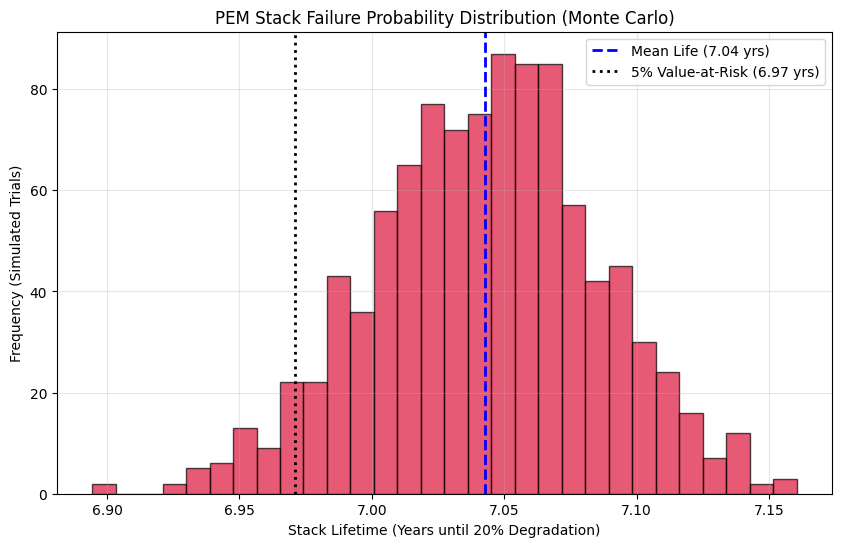

--- RISK REPORT ---
Expected Stack Lifetime: 7.04 years
95% Confidence Lifespan: The stack will last at least 6.97 years.
Financial Action Item: Budget for a stack replacement reserve fund by Year 6.97 to mitigate asset risk.


In [1]:
# Dynamic degradataion mecahnism

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. THE DYNAMIC DEGRADATION MECHANISM
# ==========================================
class DegradingPEMStack:
    def __init__(self, initial_efficiency=0.70):
        self.efficiency = initial_efficiency
        self.health = 1.0  # 1.0 = Brand new stack, 0.0 = Complete failure
        
        # Microscopic/Dynamic degradation penalty coefficients
        self.base_hourly_wear = 0.000002   # Normal steady-state wear
        self.low_load_penalty = 0.000010   # Accelerated membrane thinning from OCV/gas crossover
        self.ramping_penalty  = 0.000005   # Mechanical stress from transient cycles
        
    def step_one_hour(self, current_load, previous_load):
        """
        Calculates the damage done to the PEM stack in a single hour
        based on how dynamically it was operated.
        """
        if current_load == 0:
            return  # Stack is off, minimal/no dynamic wear
            
        # 1. Base Degradation
        hourly_damage = self.base_hourly_wear
        
        # 2. Low-Load Penalty (Operating below 15% capacity maximizes radical formation)
        if current_load < 0.15:
            hourly_damage += self.low_load_penalty
            
        # 3. Ramping Penalty (Mechanical stress from power spikes/drops)
        ramp_rate = abs(current_load - previous_load)
        if ramp_rate > 0.30:  # If power changed by more than 30% in one hour
            hourly_damage += (ramp_rate * self.ramping_penalty)
            
        # Deduct damage from health pool
        self.health -= hourly_damage
        self.health = max(0.0, self.health)
        
        # Efficiency degrades proportionally as cell voltage increases over time
        # (e.g., losing 15% of your initial health drops your efficiency)
        self.efficiency = initial_efficiency * (0.85 + 0.15 * self.health)

# ==========================================
# 2. RUNNING A LIFETIME SYSTEM SIMULATION
# ==========================================
def simulate_lifetime(renewable_profile_pool):
    """
    Simulates the PEM stack hour-by-hour across multiple years 
    until its health completely fails or hits an EOL threshold.
    """
    stack = DegradingPEMStack()
    hours_alive = 0
    previous_load = 0.0
    
    # Keep running year after year until the stack degrades past 20% of its initial health
    while stack.health > 0.80: 
        # Pick a random weather year from our historical pool (Monte Carlo sampling)
        year_idx = np.random.choice(len(renewable_profile_pool))
        yearly_profile = renewable_profile_pool[year_idx]
        
        for hour in range(8760):
            current_load = yearly_profile[hour] # e.g., 0.0 to 1.0 load factor
            
            stack.step_one_hour(current_load, previous_load)
            previous_load = current_load
            hours_alive += 1
            
            if stack.health <= 0.80:
                break # Stack hit End-of-Life (EOL)
                
    return hours_alive / 8760.0  # Return lifetime in years

# ==========================================
# 3. THE MC LOOP & VALUE AT RISK (VaR)
# ==========================================
# Creating 10 different dummy synthetic solar/wind profiles (1 year long each)
np.random.seed(101)
base_year = np.clip(np.sin(np.linspace(0, 2*np.pi*365, 8760)) + 0.2, 0, 1)
profile_pool = [np.clip(base_year + np.random.normal(0, 0.25, 8760), 0, 1) for _ in range(10)]

initial_efficiency = 0.70
mc_iterations = 1000
lifetimes = []

print(f"Simulating {mc_iterations} stack lifetimes...")
for i in range(mc_iterations):
    years_to_failure = simulate_lifetime(profile_pool)
    lifetimes.append(years_to_failure)

# Convert results to a pandas array for easy financial statistics
lifetimes = np.array(lifetimes)

# Calculate Quant Finance Risk Metrics: Value at Risk (VaR)
# 5% VaR means there is a 5% chance the stack will fail BEFORE this date.
var_5_pct = np.percentile(lifetimes, 5)
mean_lifetime = np.mean(lifetimes)

# ==========================================
# 4. VISUALIZING RISK DISPERSION
# ==========================================
plt.figure(figsize=(10, 6))
plt.hist(lifetimes, bins=30, color='crimson', alpha=0.7, edgecolor='black')
plt.axvline(mean_lifetime, color='blue', linestyle='dashed', linewidth=2, label=f'Mean Life ({mean_lifetime:.2f} yrs)')
plt.axvline(var_5_pct, color='black', linestyle='dotted', linewidth=2, label=f'5% Value-at-Risk ({var_5_pct:.2f} yrs)')

plt.title('PEM Stack Failure Probability Distribution (Monte Carlo)')
plt.xlabel('Stack Lifetime (Years until 20% Degradation)')
plt.ylabel('Frequency (Simulated Trials)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"--- RISK REPORT ---")
print(f"Expected Stack Lifetime: {mean_lifetime:.2f} years")
print(f"95% Confidence Lifespan: The stack will last at least {var_5_pct:.2f} years.")
print(f"Financial Action Item: Budget for a stack replacement reserve fund by Year {var_5_pct:.2f} to mitigate asset risk.")